# Análise de Dados — Respostas às Perguntas de Negócio

Este notebook responde as 5 perguntas de negócio definidas no objetivo do MVP, usando consultas SQL sobre o modelo dimensional (camada Gold) e visualizações em matplotlib.

**Nota metodológica:** análises que envolvem a nota da avaliação são feitas por pedido (a nota é do pedido, não do item), exceto quando a dimensão analisada é o produto/categoria — nesse caso, por item. Consideram-se apenas pedidos entregues e avaliados quando as métricas de entrega e satisfação são cruzadas.

## P1 — Atrasos na entrega reduzem a nota da avaliação?

Compara a nota média entre pedidos entregues **adiantados**, **no prazo** e **atrasados**. Análise por pedido (nota e atraso são do pedido, não do item).

In [0]:
%sql
-- P1: Atrasos na entrega reduzem a nota da avaliação?
-- Análise por PEDIDO (não por item), para não pesar pedidos com mais itens.
-- Apenas pedidos entregues e avaliados (atraso e nota não nulos).
-- Faixas de atraso: adiantado (< 0), no prazo (= 0), atrasado (> 0).
WITH pedidos AS (
    SELECT DISTINCT
        order_id,
        atraso_dias,
        review_score
    FROM ecommerce_br.gold.fato_vendas
    WHERE atraso_dias IS NOT NULL
      AND review_score IS NOT NULL
)
SELECT
    CASE
        WHEN atraso_dias < 0 THEN '1. Adiantado'
        WHEN atraso_dias = 0 THEN '2. No prazo'
        ELSE '3. Atrasado'
    END AS faixa_entrega,
    COUNT(*) AS qtd_pedidos,
    ROUND(AVG(review_score), 2) AS nota_media
FROM pedidos
GROUP BY faixa_entrega
ORDER BY faixa_entrega;

faixa_entrega,qtd_pedidos,nota_media
1. Adiantado,88168,4.29
2. No prazo,1280,4.03
3. Atrasado,6382,2.27


**Visualização:** nota média por faixa de entrega.

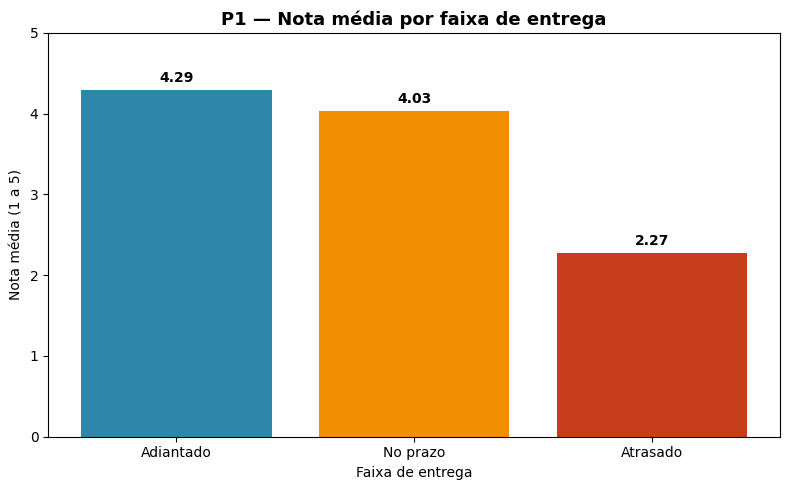

In [0]:
# Visualização da P1: nota média por faixa de entrega.
# Reexecuta a consulta via spark.sql para trazer os dados ao Python e plotar com matplotlib.
import matplotlib.pyplot as plt

df_p1 = spark.sql("""
    WITH pedidos AS (
        SELECT DISTINCT order_id, atraso_dias, review_score
        FROM ecommerce_br.gold.fato_vendas
        WHERE atraso_dias IS NOT NULL AND review_score IS NOT NULL
    )
    SELECT
        CASE
            WHEN atraso_dias < 0 THEN 'Adiantado'
            WHEN atraso_dias = 0 THEN 'No prazo'
            ELSE 'Atrasado'
        END AS faixa_entrega,
        ROUND(AVG(review_score), 2) AS nota_media
    FROM pedidos
    GROUP BY faixa_entrega
    ORDER BY MIN(atraso_dias)
""").toPandas()

# Plotagem
plt.figure(figsize=(8, 5))
barras = plt.bar(df_p1["faixa_entrega"], df_p1["nota_media"],
                 color=["#2E86AB", "#F18F01", "#C73E1D"])
plt.title("P1 — Nota média por faixa de entrega", fontsize=13, fontweight="bold")
plt.xlabel("Faixa de entrega")
plt.ylabel("Nota média (1 a 5)")
plt.ylim(0, 5)

# Rótulos de valor em cima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
             f"{altura}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Achados:** Há uma relação clara e forte entre atraso e satisfação. Pedidos entregues com atraso têm nota média de apenas **2,27**, contra **4,29** dos entregues adiantados — uma queda de mais de 2 pontos. Curiosamente, entregar "no prazo" (4,03) já é pior que "adiantado" (4,29): o cliente valoriza receber antes do previsto, não apenas na data. Como ~92% dos pedidos são entregues adiantados, isso ajuda a explicar a predominância de notas altas na base.

## P2 — Quais categorias concentram as piores avaliações? Relaciona-se a prazo ou frete?

Analisa, por categoria de produto, a nota média, o prazo médio de entrega e o frete médio. Análise **por item** (a categoria está no item). Consideram-se itens de pedidos entregues e avaliados. Filtram-se categorias com volume relevante (≥ 100 itens) para robustez.

In [0]:
%sql
-- P2: categorias com piores avaliações, cruzadas com prazo e frete.
-- Análise por item (categoria está no grão do item), juntando fato com dim_produto.
-- Apenas itens de pedidos entregues e avaliados. Categorias com >= 100 itens.
SELECT
    dp.product_category_name AS categoria,
    COUNT(*) AS qtd_itens,
    ROUND(AVG(fv.review_score), 2) AS nota_media,
    ROUND(AVG(fv.prazo_entrega_dias), 1) AS prazo_medio_dias,
    ROUND(AVG(fv.freight_value), 2) AS frete_medio
FROM ecommerce_br.gold.fato_vendas fv
JOIN ecommerce_br.gold.dim_produto dp
    ON fv.product_id = dp.product_id
WHERE fv.review_score IS NOT NULL
  AND fv.prazo_entrega_dias IS NOT NULL
GROUP BY dp.product_category_name
HAVING COUNT(*) >= 100
ORDER BY nota_media ASC
LIMIT 15;

categoria,qtd_itens,nota_media,prazo_medio_dias,frete_medio
moveis_escritorio,1654,3.51,20.8,40.12
fashion_roupa_masculina,124,3.76,12.7,16.32
telefonia_fixa,252,3.76,12.6,17.60
audio,358,3.84,13.3,15.67
casa_conforto,427,3.85,13.5,19.65
cama_mesa_banho,10831,3.92,12.7,18.43
moveis_sala,490,3.93,13.7,35.60
indefinida,1525,3.94,12.7,17.55
moveis_decoracao,8080,3.96,12.8,20.63
casa_construcao,592,3.96,13.2,22.88


**Visualização:** as 15 categorias com as piores notas médias (barras horizontais, da pior no topo).

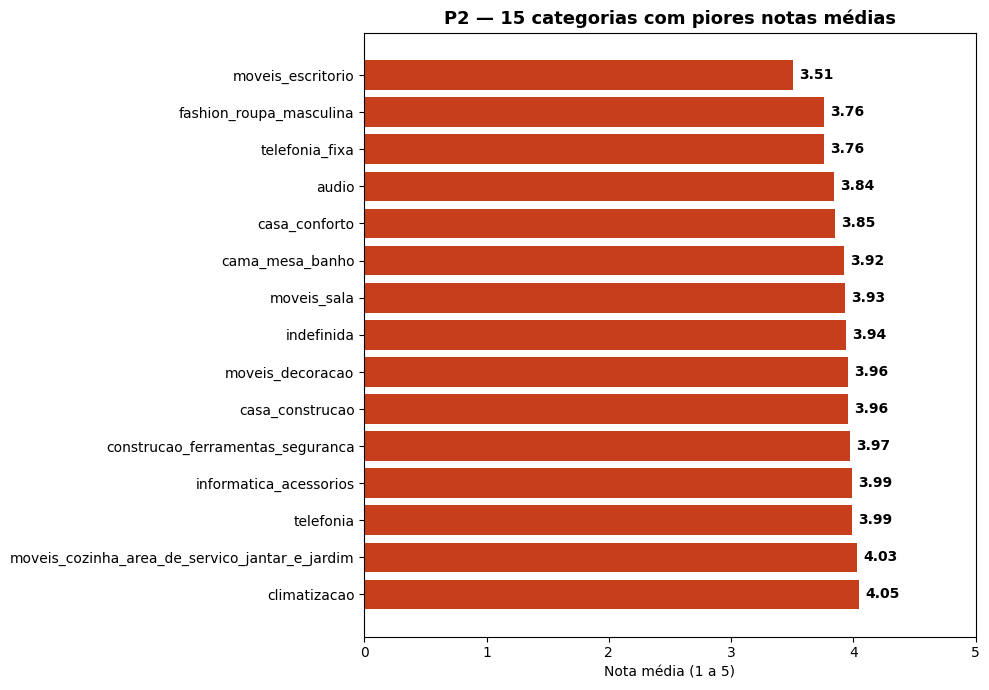

In [0]:
# Visualização da P2: as 15 categorias com piores notas médias.
import matplotlib.pyplot as plt

df_p2 = spark.sql("""
    SELECT
        dp.product_category_name AS categoria,
        ROUND(AVG(fv.review_score), 2) AS nota_media
    FROM ecommerce_br.gold.fato_vendas fv
    JOIN ecommerce_br.gold.dim_produto dp
        ON fv.product_id = dp.product_id
    WHERE fv.review_score IS NOT NULL
      AND fv.prazo_entrega_dias IS NOT NULL
    GROUP BY dp.product_category_name
    HAVING COUNT(*) >= 100
    ORDER BY nota_media ASC
    LIMIT 15
""").toPandas()

plt.figure(figsize=(10, 7))
# Barras horizontais; inverte a ordem para a pior ficar no topo
barras = plt.barh(df_p2["categoria"][::-1], df_p2["nota_media"][::-1], color="#C73E1D")
plt.title("P2 — 15 categorias com piores notas médias", fontsize=13, fontweight="bold")
plt.xlabel("Nota média (1 a 5)")
plt.xlim(0, 5)

for barra in barras:
    largura = barra.get_width()
    plt.text(largura + 0.05, barra.get_y() + barra.get_height()/2,
             f"{largura}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Achados:** As piores categorias são dominadas por **móveis e itens volumosos**. A pior, `moveis_escritorio` (nota **3,51**), combina o maior prazo de entrega (**20,8 dias**, ~60% acima da média) com um frete elevado (**R$ 40,12**). O padrão sugere que o **prazo tem relação mais forte com a insatisfação do que o frete isolado** — categorias com frete alto mas prazo normal (ex.: `moveis_cozinha`) mantêm notas razoáveis. Produtos grandes enfrentam um desafio logístico (frete caro + entrega lenta) que se reflete na avaliação.

## P3 — Fretes mais caros geram avaliações piores?

Analisa a relação entre o frete e a nota, de duas formas: (a) pelo **valor absoluto** do frete e (b) pela **proporção frete/preço** (um frete "pesa" mais quando é alto em relação ao valor do produto). Análise por item, considerando itens de pedidos avaliados.

### P3a — Frete absoluto

In [0]:
%sql
-- P3a: nota média por faixa de valor absoluto de frete.
-- Análise por item; apenas itens de pedidos avaliados.
SELECT
    CASE
        WHEN freight_value < 10 THEN '1. Até R10'
        WHEN freight_value < 20 THEN '2. R10-20'
        WHEN freight_value < 30 THEN '3. R20-30'
        WHEN freight_value < 50 THEN '4. R30-50'
        ELSE '5. Acima de R50'
    END AS faixa_frete,
    COUNT(*) AS qtd_itens,
    ROUND(AVG(review_score), 2) AS nota_media,
    ROUND(AVG(freight_value), 2) AS frete_medio_faixa
FROM ecommerce_br.gold.fato_vendas
WHERE review_score IS NOT NULL
  AND freight_value IS NOT NULL
GROUP BY faixa_frete
ORDER BY faixa_frete;

faixa_frete,qtd_itens,nota_media,frete_medio_faixa
1. Até R10,15734,4.12,7.80
2. R10-20,65026,4.05,15.50
3. R20-30,18007,3.98,23.96
4. R30-50,8344,3.9,38.23
5. Acima de R50,4597,3.89,76.50


### P3b — Frete proporcional (frete / preço)

Um frete "pesa" mais quando é alto em relação ao preço do produto. Aqui a razão frete/preço é agrupada em faixas, comparando a nota média. Considera itens com preço maior que zero.

In [0]:
%sql
-- P3b: nota media por faixa de proporção frete/preço.
-- A razão mede quanto o frete representa do valor do produto.
-- Rótulos sem cifrão para evitar o aviso de parâmetro do Databricks.
SELECT
    CASE
        WHEN freight_value / price < 0.1 THEN '1. Menos de 10%'
        WHEN freight_value / price < 0.25 THEN '2. 10-25%'
        WHEN freight_value / price < 0.5 THEN '3. 25-50%'
        WHEN freight_value / price < 1.0 THEN '4. 50-100%'
        ELSE '5. Frete >= preco'
    END AS faixa_proporcao,
    COUNT(*) AS qtd_itens,
    ROUND(AVG(review_score), 2) AS nota_media
FROM ecommerce_br.gold.fato_vendas
WHERE review_score IS NOT NULL
  AND freight_value IS NOT NULL
  AND price > 0
GROUP BY faixa_proporcao
ORDER BY faixa_proporcao;

faixa_proporcao,qtd_itens,nota_media
1. Menos de 10%,17343,4.07
2. 10-25%,42957,4.06
3. 25-50%,32630,4.02
4. 50-100%,14703,3.99
5. Frete >= preco,4075,3.84


**Visualização:** nota média por faixa de frete — absoluto (esquerda) e proporcional (direita).

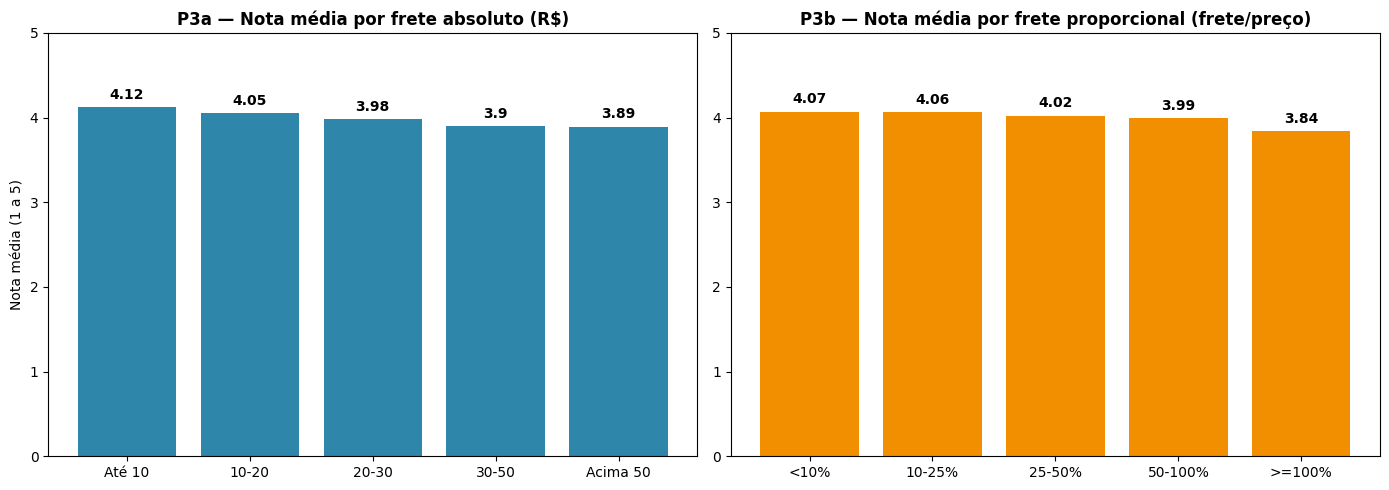

In [0]:
# Visualização da P3: frete absoluto e proporcional, lado a lado.
import matplotlib.pyplot as plt

# Dados 3a — frete absoluto
df_p3a = spark.sql("""
    SELECT
        CASE
            WHEN freight_value < 10 THEN 'Até 10'
            WHEN freight_value < 20 THEN '10-20'
            WHEN freight_value < 30 THEN '20-30'
            WHEN freight_value < 50 THEN '30-50'
            ELSE 'Acima 50'
        END AS faixa,
        ROUND(AVG(review_score), 2) AS nota_media
    FROM ecommerce_br.gold.fato_vendas
    WHERE review_score IS NOT NULL AND freight_value IS NOT NULL
    GROUP BY faixa
    ORDER BY MIN(freight_value)
""").toPandas()

# Dados 3b — frete proporcional
df_p3b = spark.sql("""
    SELECT
        CASE
            WHEN freight_value / price < 0.1 THEN '<10%'
            WHEN freight_value / price < 0.25 THEN '10-25%'
            WHEN freight_value / price < 0.5 THEN '25-50%'
            WHEN freight_value / price < 1.0 THEN '50-100%'
            ELSE '>=100%'
        END AS faixa,
        ROUND(AVG(review_score), 2) AS nota_media
    FROM ecommerce_br.gold.fato_vendas
    WHERE review_score IS NOT NULL AND freight_value IS NOT NULL AND price > 0
    GROUP BY faixa
    ORDER BY MIN(freight_value / price)
""").toPandas()

# Dois gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(df_p3a["faixa"], df_p3a["nota_media"], color="#2E86AB")
ax1.set_title("P3a — Nota média por frete absoluto (R$)", fontweight="bold")
ax1.set_ylabel("Nota média (1 a 5)")
ax1.set_ylim(0, 5)
for i, v in enumerate(df_p3a["nota_media"]):
    ax1.text(i, v + 0.1, f"{v}", ha="center", fontweight="bold")

ax2.bar(df_p3b["faixa"], df_p3b["nota_media"], color="#F18F01")
ax2.set_title("P3b — Nota média por frete proporcional (frete/preço)", fontweight="bold")
ax2.set_ylim(0, 5)
for i, v in enumerate(df_p3b["nota_media"]):
    ax2.text(i, v + 0.1, f"{v}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Achados:** O frete influencia a satisfação, mas de forma **modesta**. No valor absoluto, a nota cai de **4,12** (até R$10) para **3,89** (acima de R$50). Na proporção, o pior caso é quando o **frete custa mais que o produto** (nota **3,84**). Em ambas as visões a queda é de cerca de **0,23 ponto** — muito menor que o impacto do atraso (mais de 2 pontos na P1). **Conclusão: entre os fatores operacionais, a pontualidade é o maior determinante da satisfação; o custo do frete tem impacto secundário.**

## P4 — Quais estados têm os maiores tempos de entrega e atrasos, e quão distantes estão da média nacional?

Cruza as métricas de entrega (prazo e atraso médios) com o estado do cliente, ordenando pelos piores prazos. Análise por pedido entregue. Ao final, compara-se cada estado com a média nacional.

In [0]:
%sql
-- P4: média nacional de prazo e atraso (referência para comparação).
-- Por pedido entregue (DISTINCT para não pesar por itens).
WITH pedidos AS (
    SELECT DISTINCT
        fv.order_id,
        dc.customer_state,
        fv.prazo_entrega_dias,
        fv.atraso_dias
    FROM ecommerce_br.gold.fato_vendas fv
    JOIN ecommerce_br.gold.dim_cliente dc
        ON fv.customer_id = dc.customer_id
    WHERE fv.prazo_entrega_dias IS NOT NULL
)
SELECT
    ROUND(AVG(prazo_entrega_dias), 1) AS prazo_medio_nacional,
    ROUND(AVG(atraso_dias), 1) AS atraso_medio_nacional,
    COUNT(*) AS total_pedidos
FROM pedidos;

prazo_medio_nacional,atraso_medio_nacional,total_pedidos
12.5,-11.9,96476


### Ranking dos estados por prazo de entrega

In [0]:
%sql
-- P4: ranking dos estados por prazo médio de entrega (piores no topo).
-- Inclui atraso médio e a diferença do prazo em relação à média nacional (12.5 dias).
WITH pedidos AS (
    SELECT DISTINCT
        fv.order_id,
        dc.customer_state,
        fv.prazo_entrega_dias,
        fv.atraso_dias
    FROM ecommerce_br.gold.fato_vendas fv
    JOIN ecommerce_br.gold.dim_cliente dc
        ON fv.customer_id = dc.customer_id
    WHERE fv.prazo_entrega_dias IS NOT NULL
)
SELECT
    customer_state AS estado,
    COUNT(*) AS qtd_pedidos,
    ROUND(AVG(prazo_entrega_dias), 1) AS prazo_medio,
    ROUND(AVG(atraso_dias), 1) AS atraso_medio,
    ROUND(AVG(prazo_entrega_dias) - 12.5, 1) AS dif_prazo_vs_nacional
FROM pedidos
GROUP BY customer_state
ORDER BY prazo_medio DESC;

estado,qtd_pedidos,prazo_medio,atraso_medio,dif_prazo_vs_nacional
RR,41,29.3,-17.3,16.8
AP,67,27.2,-19.7,14.7
AM,145,26.4,-19.6,13.9
AL,397,24.5,-8.7,12.0
PA,946,23.7,-14.1,11.2
SE,335,21.5,-10.0,9.0
MA,717,21.5,-9.6,9.0
CE,1279,21.2,-10.8,8.7
AC,80,21.0,-20.7,8.5
PB,517,20.4,-13.3,7.9


**Visualização:** os 10 estados com maior prazo médio de entrega, comparados à média nacional (linha tracejada).

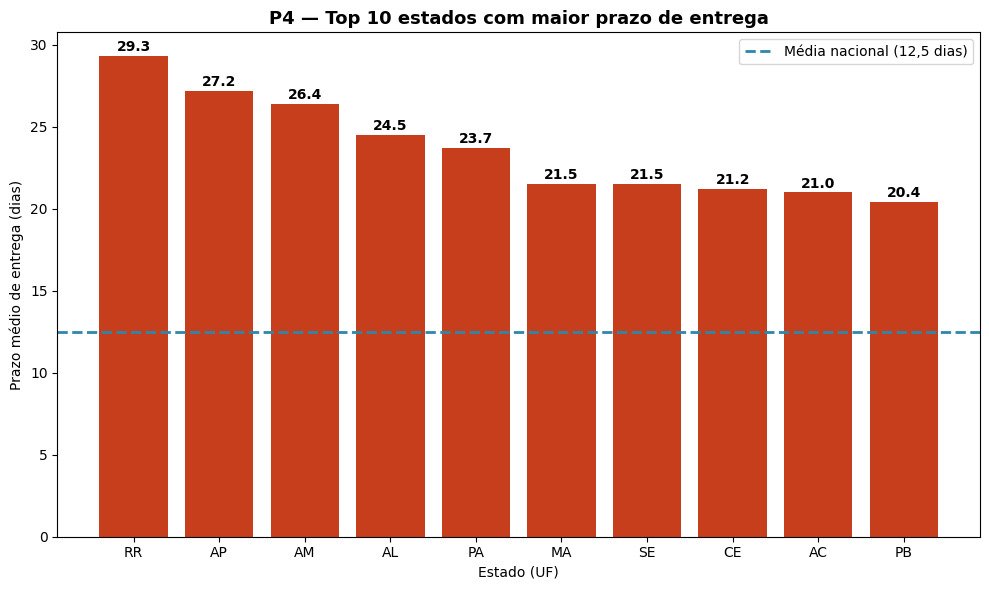

In [0]:
# Visualização da P4: 10 estados com maior prazo médio, vs média nacional.
import matplotlib.pyplot as plt

df_p4 = spark.sql("""
    WITH pedidos AS (
        SELECT DISTINCT fv.order_id, dc.customer_state, fv.prazo_entrega_dias
        FROM ecommerce_br.gold.fato_vendas fv
        JOIN ecommerce_br.gold.dim_cliente dc ON fv.customer_id = dc.customer_id
        WHERE fv.prazo_entrega_dias IS NOT NULL
    )
    SELECT customer_state AS estado, ROUND(AVG(prazo_entrega_dias),1) AS prazo_medio
    FROM pedidos GROUP BY customer_state
    ORDER BY prazo_medio DESC LIMIT 10
""").toPandas()

plt.figure(figsize=(10, 6))
barras = plt.bar(df_p4["estado"], df_p4["prazo_medio"], color="#C73E1D")
plt.axhline(y=12.5, color="#2E86AB", linestyle="--", linewidth=2, label="Média nacional (12,5 dias)")
plt.title("P4 — Top 10 estados com maior prazo de entrega", fontsize=13, fontweight="bold")
plt.xlabel("Estado (UF)")
plt.ylabel("Prazo médio de entrega (dias)")
plt.legend()

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.3,
             f"{altura}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Achados:** Há forte **desigualdade logística regional**. Os estados do Norte/Nordeste lideram os maiores prazos: Roraima (**29,3 dias**), Amapá (27,2) e Amazonas (26,4) — contra a média nacional de **12,5 dias** e apenas **8,7 dias** em São Paulo. Roraima demora mais que o **dobro** da média. Porém, um achado importante: mesmo os estados mais lentos entregam **antes do prazo previsto** (Roraima tem atraso médio de -17,3 dias). Isso indica que o marketplace **calibra a expectativa por região** — promete prazos longos para áreas distantes e os cumpre. A insatisfação desses clientes, portanto, tende a vir do **tempo absoluto de espera**, não do descumprimento da promessa.

## P5 — Clientes mais distantes enfrentam fretes/prazos maiores e notas piores?

Calcula a distância geográfica entre cliente e vendedor (fórmula de Haversine, a partir das coordenadas de CEP) e a cruza com frete, prazo e nota. Itens sem coordenada de cliente ou vendedor (CEPs ausentes na geolocation) ficam fora do cálculo de distância.

### Teste da fórmula de distância (Haversine)

In [0]:
%sql
-- P5: teste da fórmula de Haversine (distância em km entre cliente e vendedor).
-- Haversine calcula a distância na superfície da Terra (raio ~6371 km) a partir
-- de latitude/longitude. Amostra pequena para validar antes da análise completa.
SELECT
    fv.order_id,
    dc.customer_state,
    dv.seller_state,
    ROUND(
        2 * 6371 * ASIN(SQRT(
            POWER(SIN(RADIANS(dv.seller_lat - dc.customer_lat) / 2), 2) +
            COS(RADIANS(dc.customer_lat)) * COS(RADIANS(dv.seller_lat)) *
            POWER(SIN(RADIANS(dv.seller_lng - dc.customer_lng) / 2), 2)
        )), 1
    ) AS distancia_km
FROM ecommerce_br.gold.fato_vendas fv
JOIN ecommerce_br.gold.dim_cliente dc ON fv.customer_id = dc.customer_id
JOIN ecommerce_br.gold.dim_vendedor dv ON fv.seller_id = dv.seller_id
WHERE dc.customer_lat IS NOT NULL
  AND dv.seller_lat IS NOT NULL
LIMIT 10;

order_id,customer_state,seller_state,distancia_km
029b1d3a355dec12cfed60927f076a9d,RJ,SP,406.2
032b0e60cda9e20b30fc4b3bf1079e50,SP,SP,340.2
03f2f876bfee9ea9a502ec0d8a664e4c,SP,SP,139.7
03f51c9adce893f63936c5146701aa2f,PA,MG,2101.7
06be8b2c2a6e818814aa5416c3512ca3,RS,SP,818.7
07d13d352c85dfbfa60dc56dea818335,SP,SP,7.6
0814daa4d12a646aeb73c429d5852f4d,MG,MG,302.0
0818699476819463109688475b808343,SP,SP,401.3
090c44686a2c4ac5320b757784023c4b,SP,SP,299.5
09e6dfb3a40d9c2e75458a76ff06e2d5,SP,SP,33.6


### Análise: distância vs. frete, prazo e satisfação

In [0]:
%sql
-- P5: distância (Haversine) cruzada com frete, prazo e nota, por faixa de distância.
-- Por item; considera apenas vendas com coordenadas de cliente e vendedor.
WITH vendas_distancia AS (
    SELECT
        fv.review_score,
        fv.freight_value,
        fv.price,
        fv.prazo_entrega_dias,
        2 * 6371 * ASIN(SQRT(
            POWER(SIN(RADIANS(dv.seller_lat - dc.customer_lat) / 2), 2) +
            COS(RADIANS(dc.customer_lat)) * COS(RADIANS(dv.seller_lat)) *
            POWER(SIN(RADIANS(dv.seller_lng - dc.customer_lng) / 2), 2)
        )) AS distancia_km
    FROM ecommerce_br.gold.fato_vendas fv
    JOIN ecommerce_br.gold.dim_cliente dc ON fv.customer_id = dc.customer_id
    JOIN ecommerce_br.gold.dim_vendedor dv ON fv.seller_id = dv.seller_id
    WHERE dc.customer_lat IS NOT NULL
      AND dv.seller_lat IS NOT NULL
      AND fv.price > 0
)
SELECT
    CASE
        WHEN distancia_km < 50 THEN '1. Até 50 km'
        WHEN distancia_km < 200 THEN '2. 50-200 km'
        WHEN distancia_km < 500 THEN '3. 200-500 km'
        WHEN distancia_km < 1000 THEN '4. 500-1000 km'
        ELSE '5. Acima de 1000 km'
    END AS faixa_distancia,
    COUNT(*) AS qtd_itens,
    ROUND(AVG(freight_value), 2) AS frete_medio,
    ROUND(AVG(freight_value / price), 3) AS proporcao_frete_preco,
    ROUND(AVG(prazo_entrega_dias), 1) AS prazo_medio_dias,
    ROUND(AVG(review_score), 2) AS nota_media
FROM vendas_distancia
WHERE prazo_entrega_dias IS NOT NULL
GROUP BY faixa_distancia
ORDER BY faixa_distancia;

faixa_distancia,qtd_itens,frete_medio,proporcao_frete_preco,prazo_medio_dias,nota_media
1. Até 50 km,13451,11.48,0.247,6.1,4.22
2. 50-200 km,14709,13.73,0.245,7.9,4.23
3. 200-500 km,34753,19.06,0.314,12.0,4.07
4. 500-1000 km,29496,21.08,0.338,14.2,4.03
5. Acima de 1000 km,17251,31.65,0.427,19.0,3.96


**Visualização:** como frete, prazo e nota variam com a distância cliente–vendedor.

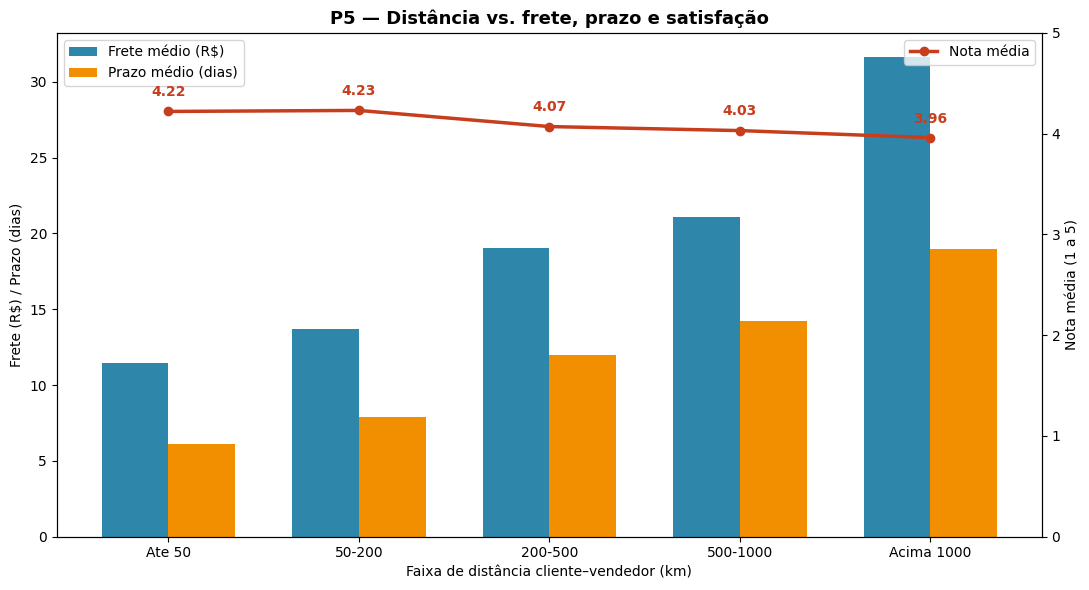

In [0]:
# Visualização da P5: frete, prazo e nota por faixa de distância.
import matplotlib.pyplot as plt

df_p5 = spark.sql("""
    WITH vendas_distancia AS (
        SELECT fv.review_score, fv.freight_value, fv.price, fv.prazo_entrega_dias,
            2 * 6371 * ASIN(SQRT(
                POWER(SIN(RADIANS(dv.seller_lat - dc.customer_lat)/2),2) +
                COS(RADIANS(dc.customer_lat))*COS(RADIANS(dv.seller_lat))*
                POWER(SIN(RADIANS(dv.seller_lng - dc.customer_lng)/2),2)
            )) AS distancia_km
        FROM ecommerce_br.gold.fato_vendas fv
        JOIN ecommerce_br.gold.dim_cliente dc ON fv.customer_id = dc.customer_id
        JOIN ecommerce_br.gold.dim_vendedor dv ON fv.seller_id = dv.seller_id
        WHERE dc.customer_lat IS NOT NULL AND dv.seller_lat IS NOT NULL AND fv.price > 0
    )
    SELECT
        CASE
            WHEN distancia_km < 50 THEN 'Ate 50'
            WHEN distancia_km < 200 THEN '50-200'
            WHEN distancia_km < 500 THEN '200-500'
            WHEN distancia_km < 1000 THEN '500-1000'
            ELSE 'Acima 1000'
        END AS faixa,
        ROUND(AVG(freight_value),2) AS frete_medio,
        ROUND(AVG(prazo_entrega_dias),1) AS prazo_medio,
        ROUND(AVG(review_score),2) AS nota_media
    FROM vendas_distancia
    WHERE prazo_entrega_dias IS NOT NULL
    GROUP BY faixa
    ORDER BY MIN(distancia_km)
""").toPandas()

fig, ax1 = plt.subplots(figsize=(11, 6))

# Eixo esquerdo: frete e prazo (barras)
x = range(len(df_p5))
largura = 0.35
ax1.bar([i - largura/2 for i in x], df_p5["frete_medio"], largura, label="Frete médio (R$)", color="#2E86AB")
ax1.bar([i + largura/2 for i in x], df_p5["prazo_medio"], largura, label="Prazo médio (dias)", color="#F18F01")
ax1.set_xlabel("Faixa de distância cliente–vendedor (km)")
ax1.set_ylabel("Frete (R$) / Prazo (dias)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_p5["faixa"])
ax1.legend(loc="upper left")

# Eixo direito: nota (linha)
ax2 = ax1.twinx()
ax2.plot(x, df_p5["nota_media"], color="#C73E1D", marker="o", linewidth=2.5, label="Nota média")
ax2.set_ylabel("Nota média (1 a 5)")
ax2.set_ylim(0, 5)
ax2.legend(loc="upper right")

for i, v in enumerate(df_p5["nota_media"]):
    ax2.text(i, v + 0.15, f"{v}", ha="center", color="#C73E1D", fontweight="bold")

plt.title("P5 — Distância vs. frete, prazo e satisfação", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Achados:** A distância entre cliente e vendedor tem impacto **forte na operação, modesto na percepção**. Ao passar de "até 50 km" para "acima de 1000 km": o frete médio quase **triplica** (R$ 11,48 → R$ 31,65), o frete chega a representar **43%** do preço do produto, e o prazo mais que triplica (6,1 → 19,0 dias). A nota, porém, cai apenas de **4,22 para 3,96**. Isso reforça a conclusão central do estudo: o cliente aceita pagar mais e esperar mais por distância — **o que realmente derruba a satisfação é a quebra da promessa (atraso), não a distância em si**.